# Overview

This file focuses on data cleaning and preprocessing to prepare the MINDS news recommendation dataset for further Exploratory Data Analysis (EDA) later on. We begin by loading the data and establishing a **global index** for consistent tracking of users and news items. We then normalise the metadata by merging sparse categories and creating defined sub-clusters to make the news data more structured and manageable for analysis. After **handling missing values** in critical news text fields like entities and abstracts, categorical labels are encoded into numerical formats. Finally,we perform a **temporal split** of the data to produce our training, validation and tests sets. Lastly, **negative sampling** is performed on the **training** set.

In [ ]:
!pip install -q kagglehub pandas
!pip install spacy

import kagglehub
import pandas as pd
import os
import ast
import spacy

# Load in MINDS Dataset

In [ ]:
#Download MINDS dataset
path = kagglehub.dataset_download("arashnic/mind-news-dataset")

#Training Folder
train_path = os.path.join(path, "MINDsmall_train")

#Load datasets
behaviors = pd.read_csv(os.path.join(train_path, "behaviors.tsv"), sep="\t", header=None)
news = pd.read_csv(os.path.join(train_path, "news.tsv"), sep="\t", header=None)

#Add in the column names
behaviors.columns = ["impression_id","user_id","time","history","impressions"]
news.columns = ["news_id","category","subcategory","title","abstract","url","title_entities","abstract_entities"]

print("Users:", behaviors["user_id"].nunique())
print("Articles:", news["news_id"].nunique())

#There are 3238 users with no user history
#Good for models to learn
print("Number of duplicates:", behaviors.duplicated().sum())
behaviors.drop_duplicates(inplace=True)
print(behaviors.isnull().sum())

# total number of rows for behaviours.tsv
print("Total instances in behaviors:", len(behaviors))

# total number of instances for news.tsv
print("Total instances in news:", len(news))

Using Colab cache for faster access to the 'mind-news-dataset' dataset.
Users: 50000
Articles: 51282
Number of duplicates: 0
impression_id       0
user_id             0
time                0
history          3238
impressions         0
dtype: int64
Total instances in behaviors: 156965
Total instances in news: 51282


In [ ]:
import pandas as pd
import json
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
news_map_path = '/content/drive/MyDrive/data/global_id_mappings/global_news_id_map.json'
user_map_path = '/content/drive/MyDrive/data/global_id_mappings/global_user_id_map.json'

In [ ]:
with open(news_map_path, 'r') as f:
    news_id_map = json.load(f)

with open(user_map_path, 'r') as f:
    user_id_map = json.load(f)

# 3. Replace Original Columns with Mapped Integers/Lists
# Replace News IDs in Metadata
news['news_id'] = news['news_id'].map(news_id_map)

# Replace User IDs in Behaviors
behaviors['user_id'] = behaviors['user_id'].map(user_id_map)

# Replace History String with List of Integers
def parse_history(h_str):
    if pd.isna(h_str) or h_str == "": return []
    return [news_id_map.get(nid, 0) for nid in h_str.split()]

behaviors['history'] = behaviors['history'].apply(parse_history)

# Parse Impressions into Positive and Negative Lists
def parse_impressions(imp_str):
    pos_ids, neg_ids = [], []
    for item in imp_str.split():
        nid, label = item.split('-')
        int_id = news_id_map.get(nid, 0)
        if label == '1': pos_ids.append(int_id)
        else: neg_ids.append(int_id)
    return pos_ids, neg_ids

# We replace 'impressions' with pos and neg lists to save space and compute
behaviors['pos_ids'], behaviors['neg_ids'] = zip(*behaviors['impressions'].apply(parse_impressions))
behaviors.drop(columns=['impressions'], inplace=True)

# 4. Verification
print(f"User ID type: {type(behaviors['user_id'].iloc[0])}")
print(f"News ID type: {type(news['news_id'].iloc[0])}")
print("Example History List:", behaviors['history'].iloc[0])

User ID type: <class 'numpy.int64'>
News ID type: <class 'numpy.int64'>
Example History List: [26659, 7649, 10157, 13853, 11735, 5063, 22437, 6333, 144]


#1. Common Data Preparation

##1.1 Global Data Indexing and Structural Parsing
* Convert `user_id` and `news_id` strings into a continuous range of integers
* Update the news_id data in the `behaviors.tsv` as well, such that the news_id in `impressions` and `history` is correctly mapped
* Transform the space-separated history string into a Python list of mapped integers.
* Parse the hyphenated `impressions`
 string (e.g., N123-1) to extract and map news IDs while separating them into `pos_ids` and `neg_ids` lists based on their labels.


In [ ]:
# Check data types and example values
print(f"User ID type: {type(behaviors['user_id'].iloc[0])}")
print(f"News ID type: {type(news['news_id'].iloc[0])}")
print("Example News ID:", news['news_id'].iloc[0])
print("Example Behaviours ID:", behaviors['user_id'].iloc[0])

User ID type: <class 'numpy.int64'>
News ID type: <class 'numpy.int64'>
Example News ID: 26629
Example Behaviours ID: 1


In [ ]:
# 1. Create temporary columns for counts
behaviors['pos_count'] = behaviors['pos_ids'].map(len)
behaviors['neg_count'] = behaviors['neg_ids'].map(len)

# 2. Calculate global totals
total_pos_interactions = behaviors['pos_count'].sum()
total_neg_interactions = behaviors['neg_count'].sum()
total_impressions = len(behaviors)

# 3. Calculate global ratio
global_ratio = total_neg_interactions / total_pos_interactions

print(f"--- Global Behavior Statistics ---")
print(f"Total Impressions (Rows):  {total_impressions:,}")
print(f"Total Positive Clicks:     {total_pos_interactions:,}")
print(f"Total Negative Views:      {total_neg_interactions:,}")
print(f"Overall Ratio:             1 positive to {global_ratio:.2f} negatives")

--- Global Behavior Statistics ---
Total Impressions (Rows):  156,965
Total Positive Clicks:     236,344
Total Negative Views:      5,607,100
Overall Ratio:             1 positive to 23.72 negatives


#2. News Metadata Normalisation

## 2.1 Initial Analysis
* We found that across the news articles, there are 17 unique categories and 264 unique subcategories
* We found that several categories (e.g. lifestyle) contained up to 47 subcategories, while some categories (e.g. middleeast, northamerica) consisted of one sucategory only

In [ ]:
news.head()

,news_id,category,subcategory,title,abstract,url,title_entities,abstract_entities
0,26629,lifestyle,lifestyleroyals,"The Brands Queen Elizabeth, Prince Charles, an...","Shop the notebooks, jackets, and more that the...",https://assets.msn.com/labs/mind/AAGH0ET.html,"[{""Label"": ""Prince Philip, Duke of Edinburgh"",...",[]
1,45241,health,weightloss,50 Worst Habits For Belly Fat,These seemingly harmless habits are holding yo...,https://assets.msn.com/labs/mind/AAB19MK.html,"[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik...","[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik..."
2,49591,news,newsworld,The Cost of Trump's Aid Freeze in the Trenches...,Lt. Ivan Molchanets peeked over a parapet of s...,https://assets.msn.com/labs/mind/AAJgNsz.html,[],"[{""Label"": ""Ukraine"", ""Type"": ""G"", ""WikidataId..."
3,28765,health,voices,I Was An NBA Wife. Here's How It Affected My M...,"I felt like I was a fraud, and being an NBA wi...",https://assets.msn.com/labs/mind/AACk2N6.html,[],"[{""Label"": ""National Basketball Association"", ..."
4,28005,health,medical,"How to Get Rid of Skin Tags, According to a De...","They seem harmless, but there's a very good re...",https://assets.msn.com/labs/mind/AAAKEkt.html,"[{""Label"": ""Skin tag"", ""Type"": ""C"", ""WikidataI...","[{""Label"": ""Skin tag"", ""Type"": ""C"", ""WikidataI..."


In [ ]:
# Number of unique categories
num_categories = news['category'].nunique()
print("Number of unique categories:", num_categories)

# List of all unique categories
unique_categories = news['category'].unique()
print("Unique categories:", unique_categories)

#There are around 17 unique categories. There are too few categories to conduct meaningful analysis

Number of unique categories: 17
Unique categories: ['lifestyle' 'health' 'news' 'sports' 'weather' 'entertainment' 'autos'
 'travel' 'foodanddrink' 'tv' 'finance' 'movies' 'video' 'music' 'kids'
 'middleeast' 'northamerica']


In [ ]:
# Number of unique subcategories
num_subcategories = news['subcategory'].nunique()
print("Number of unique subcategories:", num_subcategories)

# List of all unique subcategories
unique_subcategories = news['subcategory'].unique()
print("Unique subcategories:", unique_subcategories)

#There are 264 subcategories. There is too many subcategories for meaningful analysis

Number of unique subcategories: 264
Unique subcategories: ['lifestyleroyals' 'weightloss' 'newsworld' 'voices' 'medical'
 'football_nfl' 'weathertopstories' 'gaming' 'newsscienceandtechnology'
 'nutrition' 'autosenthusiasts' 'wellness' 'health-news' 'celebrity'
 'travelarticle' 'autossuvs' 'newspolitics' 'traveltripideas' 'autosnews'
 'newsbusiness' 'golf' 'lifestylepetsanimals' 'recipes' 'tv-gallery'
 'basketball_nba' 'lifestylebuzz' 'shop-all' 'newsphotos'
 'basketball_ncaa' 'finance-real-estate' 'quickandeasy' 'tv-celebrity'
 'travelnews' 'movies-gallery' 'tipsandtricks' 'autosbuying' 'more_sports'
 'shop-apparel' 'autostrucks' 'lifestyledidyouknow' 'racing' 'newstrends'
 'restaurantsandnews' 'lifestylemindandsoul' 'baseball_mlb'
 'finance-saving-investing' 'viral' 'finance-taxes' 'lifestylebeauty'
 'newsopinion' 'finance-companies' 'lifestyleshopping' 'finance-savemoney'
 'mentalhealth' 'newsus' 'lifestylesmartliving' 'fitness' 'autosclassics'
 'news' 'finance-career' 'lifestylehor

In [ ]:
#Understand what subcategories and how many are under subcategories are under each of the 17 categories
subcategories_list = news.groupby('category')['subcategory'].unique()
print(subcategories_list)

category
autos            [autosenthusiasts, autossuvs, autosnews, autos...
entertainment    [gaming, celebrity, entertainment-celebrity, e...
finance          [finance-real-estate, finance-saving-investing...
foodanddrink     [recipes, quickandeasy, tipsandtricks, newstre...
health           [weightloss, voices, medical, nutrition, welln...
kids                 [fun, video, science, people-places, animals]
lifestyle        [lifestyleroyals, lifestylepetsanimals, lifest...
middleeast                                [middleeast-top-stories]
movies           [movies-gallery, movievideo, movies-celebrity,...
music            [musicnews, music-gallery, musicvideos, music-...
news             [newsworld, newsscienceandtechnology, newspoli...
northamerica                                  [northamerica-video]
sports           [football_nfl, golf, basketball_nba, basketbal...
travel           [travelarticle, traveltripideas, travelnews, t...
tv               [tv-gallery, tv-celebrity, tvnews, h

In [ ]:
#Understand the number of subcategories per category
subcategories_count = news.groupby('category')['subcategory'].nunique()
print(subcategories_count)
#From data, there are indeed some category that has barely any subcategories
# and vice versa
#This means that category needs to be engineered

category
autos            24
entertainment    15
finance          32
foodanddrink     16
health           20
kids              5
lifestyle        47
middleeast        1
movies            7
music            11
news             33
northamerica      1
sports           31
travel           14
tv               10
video            14
weather           2
Name: subcategory, dtype: int64


In [ ]:
#Number of articles per subcategory
subcat_counts = news.groupby('subcategory')['news_id'].count().sort_values(ascending=False)
#Subcategories with many articles
print(subcat_counts.head(20))
#Subcategories with very few articles
print(subcat_counts.tail(20))

subcat_counts.describe()
#There are some subcategories with too many articles, and there are some categories with too few articles

subcategory
newsus                      6564
football_nfl                5420
newspolitics                2826
newscrime                   2254
weathertopstories           2047
newsworld                   1720
football_ncaa               1665
baseball_mlb                1661
basketball_nba              1555
newsscienceandtechnology    1210
news                        1185
newstrends                  1176
more_sports                 1065
travelarticle               1042
travelnews                   902
lifestylebuzz                894
autosnews                    837
basketball_ncaa              774
financenews                  697
finance-real-estate          584
Name: news_id, dtype: int64
subcategory
mmaufc                          1
lifestylewhatshot               1
newsvideo                       1
causes-disaster-relief          1
relationships                   1
causes-military-appreciation    1
olympics-videos                 1
othersports                     1
northamerica-vid

,news_id
count,264.000000
mean,194.250000
std,631.211339
min,1.000000
25%,2.000000
50%,15.500000
75%,110.250000
max,6564.000000


## 2.2 Combining Categories

* The dataset presents a challenge for analysis due to the distribution of categories and subcategories. There are too few main categories to provide meaningful insights, yet there are too many subcategories to analyse effectively.

* The distribution of articles per subcategory is highly imbalanced: while the 75th percentile contains only 110 articles, the standard deviation is around 600. This indicates that some subcategories have a disproportionately large number of articles.

* This means that some subcategories have enough news articles to be considered as a **standalone category**, whereas other subcategories have too few articles to be considered as a category.

* Consequently, new categories need to be made and process is shown below.



### 2.2.1 Merging Categories

- Subcategories with number of news articles > threshold are considered a category.
- Subcategories with number of news articles < threshold will be merged together with other subcateogories that fall under same category. The name of the new category is called "{category}_general"
- Threshold will be based on the 75th percentile to decide which subcategories are significant enough to remain as an independent category



In [ ]:
# Decide on the threshold
# Threshold will be based on the 75th percentile to decide which subcategories are significant enough
# To be retained as the own category
threshold = 110

# Count articles per category-subcategory
cat_subcat_counts = news.groupby(['category', 'subcategory'])['news_id'].count()
def merge_rare_subcats(row):
    count = cat_subcat_counts[row['category'], row['subcategory']]
    if count < threshold:
        return f"{row['category']}_general"
    else:
        return row['subcategory']
news['newcategory'] = news.apply(merge_rare_subcats, axis=1)
news.head()

,news_id,category,subcategory,title,abstract,url,title_entities,abstract_entities,newcategory
0,26629,lifestyle,lifestyleroyals,"The Brands Queen Elizabeth, Prince Charles, an...","Shop the notebooks, jackets, and more that the...",https://assets.msn.com/labs/mind/AAGH0ET.html,"[{""Label"": ""Prince Philip, Duke of Edinburgh"",...",[],lifestyleroyals
1,45241,health,weightloss,50 Worst Habits For Belly Fat,These seemingly harmless habits are holding yo...,https://assets.msn.com/labs/mind/AAB19MK.html,"[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik...","[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik...",weightloss
2,49591,news,newsworld,The Cost of Trump's Aid Freeze in the Trenches...,Lt. Ivan Molchanets peeked over a parapet of s...,https://assets.msn.com/labs/mind/AAJgNsz.html,[],"[{""Label"": ""Ukraine"", ""Type"": ""G"", ""WikidataId...",newsworld
3,28765,health,voices,I Was An NBA Wife. Here's How It Affected My M...,"I felt like I was a fraud, and being an NBA wi...",https://assets.msn.com/labs/mind/AACk2N6.html,[],"[{""Label"": ""National Basketball Association"", ...",health_general
4,28005,health,medical,"How to Get Rid of Skin Tags, According to a De...","They seem harmless, but there's a very good re...",https://assets.msn.com/labs/mind/AAAKEkt.html,"[{""Label"": ""Skin tag"", ""Type"": ""C"", ""WikidataI...","[{""Label"": ""Skin tag"", ""Type"": ""C"", ""WikidataI...",medical


In [ ]:
new_category_count = news['newcategory'].nunique()
print(new_category_count)

83


In [ ]:
articles_per_newcategory = news.groupby('newcategory')['news_id'].count().sort_values(ascending=False)
print(articles_per_newcategory.tail(10))
articles_per_newcategory.describe()

#From here, there are still some new categories that are too small to stand alone as a category
#Merging needs to be done

newcategory
finance-top-stocks       117
elections-2020-us        116
gaming                   115
tennis                   111
entertainment-books      110
entertainment_general     88
kids_general              17
middleeast_general         2
northamerica_general       1
weather_general            1
Name: news_id, dtype: int64


,news_id
count,83.000000
mean,617.855422
std,1015.430812
min,1.000000
25%,151.500000
50%,251.000000
75%,575.500000
max,6564.000000


### 2.2.2 Final Categories
The initial draft of categories was revised. Subcategories from kids_general onwards were merged into a "miscellaneous" category because they were both too small in terms of article count and also general in scope, making them unreliable for meaningful analysis. Merging these subcategories ensures that the remaining categories have sufficient representation, reduces noise, and improves the overall balance of the dataset.

In [ ]:
threshold = 100
articles_per_subcategory = news['newcategory'].value_counts()
def merge_small_categories(x):
    if articles_per_subcategory[x] < threshold:
        return "miscellaneous"
    else:
        return x

news['newcategory'] = news['newcategory'].apply(merge_small_categories)
print(news['newcategory'].value_counts())
print(news['newcategory'].unique())

newcategory
newsus                 6564
football_nfl           5420
newspolitics           2826
newscrime              2254
weathertopstories      2047
                       ... 
elections-2020-us       116
gaming                  115
tennis                  111
entertainment-books     110
miscellaneous           109
Name: count, Length: 79, dtype: int64
['lifestyleroyals' 'weightloss' 'newsworld' 'health_general' 'medical'
 'football_nfl' 'weathertopstories' 'gaming' 'newsscienceandtechnology'
 'nutrition' 'autosenthusiasts' 'wellness' 'health-news' 'celebrity'
 'travelarticle' 'autos_general' 'newspolitics' 'traveltripideas'
 'autosnews' 'news_general' 'golf' 'lifestyle_general' 'recipes'
 'tv_general' 'basketball_nba' 'lifestylebuzz' 'basketball_ncaa'
 'finance-real-estate' 'foodanddrink_general' 'tv-celebrity' 'travelnews'
 'movies_general' 'tipsandtricks' 'more_sports' 'racing' 'newstrends'
 'restaurantsandnews' 'baseball_mlb' 'finance_general' 'viral'
 'newsopinion' 'finance-com

In [ ]:
# drop old category and subcategory columns
news.drop(['category', 'subcategory'], axis=1, inplace=True)

# rename newcategory to simply category
news.rename(columns={'newcategory': 'category'}, inplace=True)

In [ ]:
news.drop(columns=['url'], inplace=True)
print(news.columns.tolist())

['news_id', 'title', 'abstract', 'title_entities', 'abstract_entities', 'category']


## 2.3 Creating sub-clusters of dominating categories
Certain categories like `newsus` (originally a subcategory) are generic and dominate in terms of number of articles and requires sub-clustering to better represent user preferences.

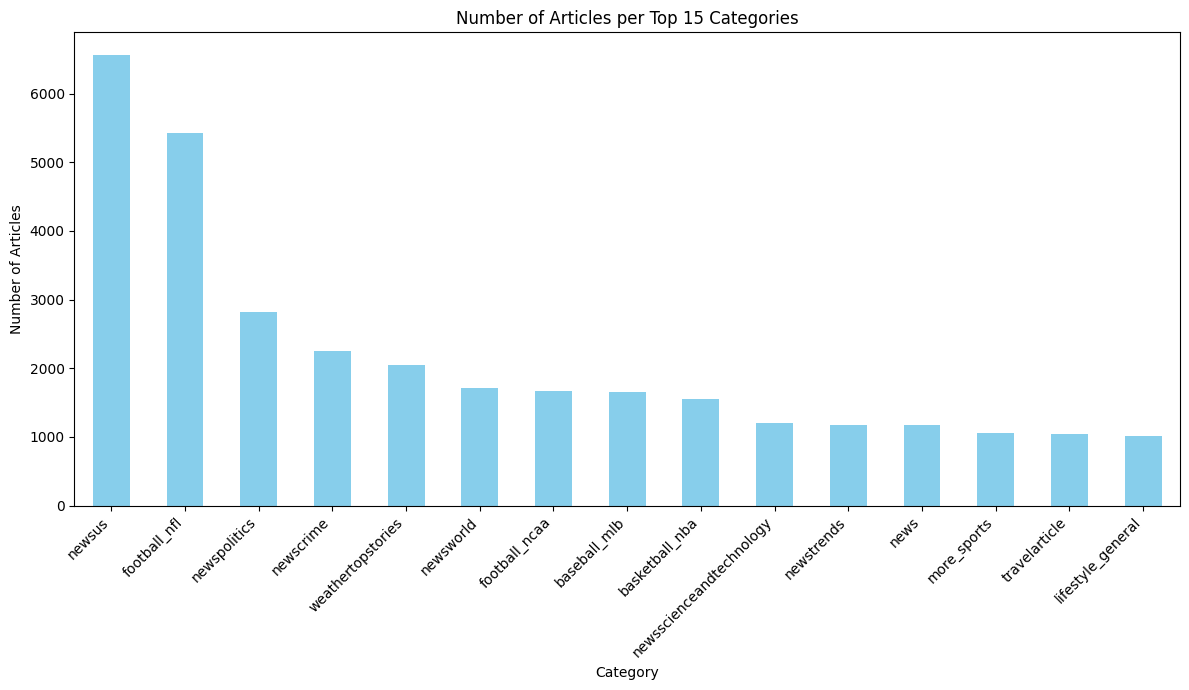

In [ ]:
import matplotlib.pyplot as plt

# Get the counts for each subclustered category
category_counts = news['category'].value_counts()

# Select the top 15 categories
top_15_categories = category_counts.head(15)

# Create the histogram (bar chart for categorical data)
plt.figure(figsize=(12, 7))
top_15_categories.plot(kind='bar', color='skyblue')
plt.title('Number of Articles per Top 15 Categories')
plt.xlabel('Category')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

### 2.3.1 Deciding which categories to sub-cluster

To identify which new categories warrant deeper sub-clustering, we examined the distribution of new categories via percentage shares and cumsum.


In [ ]:
category_counts = news['category'].value_counts()
total_articles = len(news)

print("Number of articles per category")
print(category_counts[:10])

# Calculate percentage of articles for each category
category_percentages = (category_counts / total_articles) * 100

# Sort by percentage in descending order
category_percentages = category_percentages.sort_values(ascending=False)

# Calculate cumulative percentage
cumulative_percentages = category_percentages.cumsum()

# Identify categories that make up the first 50%
dominant_categories_50 = cumulative_percentages[cumulative_percentages <= 50]


print("\nCategories making up approximately the first 50% of articles:")
print(dominant_categories_50)
print(f"\nTotal percentage: {dominant_categories_50.sum():.2f}%")

# Identify categories that make up the first 70%
dominant_categories_70 = cumulative_percentages[cumulative_percentages <= 70]


print("\nCategories making up approximately the first 70% of articles:")
print(dominant_categories_70)
print(f"\nTotal percentage: {dominant_categories_70.sum():.2f}%")


Number of articles per category
category
newsus                      6564
football_nfl                5420
newspolitics                2826
newscrime                   2254
weathertopstories           2047
newsworld                   1720
football_ncaa               1665
baseball_mlb                1661
basketball_nba              1555
newsscienceandtechnology    1210
Name: count, dtype: int64

Categories making up approximately the first 50% of articles:
category
newsus               12.799813
football_nfl         23.368823
newspolitics         28.879529
newscrime            33.274833
weathertopstories    37.266487
newsworld            40.620491
football_ncaa        43.867244
baseball_mlb         47.106197
Name: count, dtype: float64

Total percentage: 267.18%

Categories making up approximately the first 70% of articles:
category
newsus                      12.799813
football_nfl                23.368823
newspolitics                28.879529
newscrime                   33.274833
weat

Based on these results, we will **subcluster the top 8 largest categories** as it will capture granular interests for approximately 50% of the total article volume. This ensures high resolution where the most data exists, while preventing 'the curse of dimensionality' and data sparsity in the smaller, long-tail categories.

In [ ]:
import numpy as np
from google.colab import drive

drive.mount('/content/drive')

embeddings_path = '/content/drive/MyDrive/embeddings/title_abstract_embeddings.npy'

title_abstract_embeddings = np.load(embeddings_path)

print(f"Shape of title_abstract_embeddings: {title_abstract_embeddings.shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape of title_abstract_embeddings: (51282, 768)


### 2.3.2 Creating the sub-clustered categories

We perform subclustering based on the `title_abstract_embeddings`. This process involves:

1.  **Extracting Embeddings:** Retrieving the `title_abstract_embeddings` for articles within each of these top categories.
2.  **KMeans Clustering:** Applying KMeans clustering (with 3 subclusters) to these embeddings to group similar articles within the same broad category.
3.  **Creating New Labels:** Assigning new labels (e.g., `newsus_subcluster_0`, `newsus_subcluster_1`) to distinguish these subclusters.
4.  **Updating News DataFrame:** Adding a new column `subclustered_category` to the `news` DataFrame to store these refined category assignments.

In [ ]:
from sklearn.cluster import KMeans

# List of top 8 categories to subcluster
top_8_categories = [
    'newsus',
    'football_nfl',
    'newspolitics',
    'newscrime',
    'weathertopstories',
    'newsworld',
    'football_ncaa',
    'baseball_mlb'
]

# Initialize a new column for subclustered categories, defaulting to the original category
news['subclustered_category'] = news['category']

# Define the number of subclusters for each dominant category
n_subclusters = 3  # This can be adjusted based on desired granularity or further analysis

print("Starting subclustering for top categories...")

for category_name in top_8_categories:
    print(f"Processing category: {category_name}")

    # 1. Filter news articles belonging to the current category
    category_news_df = news[news['category'] == category_name].copy()

    if not category_news_df.empty:
        # 2. Get the original indices of these articles in the 'news' DataFrame
        original_indices = category_news_df.index

        # 3. Extract the corresponding embeddings
        # We assume that the index of news DataFrame rows corresponds to the index in title_abstract_embeddings
        embeddings_for_category = title_abstract_embeddings[original_indices]

        # 4. Perform KMeans clustering if there are enough samples
        if len(embeddings_for_category) >= n_subclusters:
            kmeans = KMeans(n_clusters=n_subclusters, random_state=42, n_init=10) # n_init to suppress warning
            cluster_labels = kmeans.fit_predict(embeddings_for_category)

            # 5. Create a mapping from original index to new subclustered category name
            subcluster_map = {
                idx: f"{category_name}_subcluster_{label}"
                for idx, label in zip(original_indices, cluster_labels)
            }

            # 6. Update the 'subclustered_category' column in the main 'news' DataFrame
            news.loc[original_indices, 'subclustered_category'] = news.loc[original_indices].index.map(subcluster_map)
            print(f"  - Subclustered '{category_name}' into {n_subclusters} groups.")
        else:
            print(f"  - Not enough samples ({len(embeddings_for_category)}) for clustering in '{category_name}'. Skipping subclustering for this category.")
    else:
        print(f"  - No articles found for category: '{category_name}'. Skipping.")

print("\nSubclustering complete.")
print("\nNew 'subclustered_category' column added to news DataFrame.")
print("Sample of news DataFrame with new column:")
display(news[['news_id', 'category', 'subclustered_category']].sample(10))
print("\nValue counts for the new 'subclustered_category' column (top 20):")
display(news['subclustered_category'].value_counts().head(20))

Starting subclustering for top categories...
Processing category: newsus
  - Subclustered 'newsus' into 3 groups.
Processing category: football_nfl
  - Subclustered 'football_nfl' into 3 groups.
Processing category: newspolitics
  - Subclustered 'newspolitics' into 3 groups.
Processing category: newscrime
  - Subclustered 'newscrime' into 3 groups.
Processing category: weathertopstories
  - Subclustered 'weathertopstories' into 3 groups.
Processing category: newsworld
  - Subclustered 'newsworld' into 3 groups.
Processing category: football_ncaa
  - Subclustered 'football_ncaa' into 3 groups.
Processing category: baseball_mlb
  - Subclustered 'baseball_mlb' into 3 groups.

Subclustering complete.

New 'subclustered_category' column added to news DataFrame.
Sample of news DataFrame with new column:


,news_id,category,subclustered_category
16693,45014,newsscienceandtechnology,newsscienceandtechnology
14013,13974,newsscienceandtechnology,newsscienceandtechnology
14244,38299,football_nfl,football_nfl_subcluster_0
33416,23895,newsus,newsus_subcluster_0
1288,8283,football_nfl,football_nfl_subcluster_2
42028,42644,newstrends,newstrends
18019,40459,news,news
17571,15055,science,science
43596,32850,newsus,newsus_subcluster_0
3324,640,movies_general,movies_general



Value counts for the new 'subclustered_category' column (top 20):


,count
subclustered_category,
newsus_subcluster_0,2484
football_nfl_subcluster_1,2186
newsus_subcluster_2,2087
newsus_subcluster_1,1993
football_nfl_subcluster_2,1789
basketball_nba,1555
football_nfl_subcluster_0,1445
newsscienceandtechnology,1210
newstrends,1175


###2.3.3 Analysing and naming the sub-clustered categories

To effectively rename the newly created sub-clustered categories, we'll examine a sample of article titles and abstracts from each one. This qualitative analysis will help us understand the distinct themes and topics within each subcluster, allowing for more descriptive and meaningful names.

In [ ]:
import pandas as pd

# List of top 8 categories that were subclustered
top_8_categories = [
    'newsus',
    'football_nfl',
    'newspolitics',
    'newscrime',
    'weathertopstories',
    'newsworld',
    'football_ncaa',
    'baseball_mlb'
]

n_subclusters = 3 # As defined in the subclustering step
sample_size = 3 # Number of articles to sample per subcluster

print("--- Sample Articles for Subcluster Analysis ---")
print("Review these samples to identify common themes and rename the subclusters.")

for category_name in top_8_categories:
    print(f"\nCategory: {category_name}")
    for i in range(n_subclusters):
        subcluster_name = f"{category_name}_subcluster_{i}"

        # Filter news articles belonging to the current subcluster
        subcluster_news_df = news[news['subclustered_category'] == subcluster_name]

        if not subcluster_news_df.empty:
            print(f"  Subcluster: {subcluster_name}")
            # Sample articles, ensuring there are enough articles to sample without replacement
            sampled_articles = subcluster_news_df.sample(min(len(subcluster_news_df), sample_size), random_state=42)

            for idx, row in sampled_articles.iterrows():
                print(f"    - Title: {row['title']}")
                print(f"      Abstract: {row['abstract']}")
        else:
            print(f"  Subcluster: {subcluster_name} - No articles found.")

print("\n--- End of Subcluster Analysis Samples ---")


--- Sample Articles for Subcluster Analysis ---
Review these samples to identify common themes and rename the subclusters.

Category: newsus
  Subcluster: newsus_subcluster_0
    - Title: Border Patrol Agent Arrested for Soliciting Transgender Undocumented Immigrant Prostitute
      Abstract: Garcia-Garcia stated she had resorted to prostitution because of difficulty obtaining legitimate employment due to being transgender and (an undocumented immigrant).
    - Title: Vote 'Yes' or vote 'No'? Oct. 29 forum will pit St. Paul's organized trash fans, foes
      Abstract: The League of Women Voters is organizing an election-related forum on garbage, and nothing but garbage. Four representatives from the "Vote Yes" and "Vote No" camps have been invited to sound off on St. Paul's ballot referendum, which asks voters whether to endorse or repeal city Ordinance 18-39. The ordinance played a key role in […]
    - Title: Apple credit card under fire for alleged gender bias
      Abstract: Apple'

### 2.3.4 Renaming Sub-clustered Categories

Based on the sample articles reviewed, we define more descriptive names the subclusters. Our code below is a mapping from the current `_subcluster_` names to your our chosen new names. Non-subclustered categories will retain their original names.

In [ ]:
# Define your renaming map based on your analysis
subcluster_renaming_map = {
    'newsus_subcluster_0': 'US_SocialJustice',
    'newsus_subcluster_1': 'US_ColdCases_PoliceMisconduct',
    'newsus_subcluster_2': 'US_CommunityDevelopment_FamilyLife',
    'football_nfl_subcluster_0': 'NFL_StarPlayers',
    'football_nfl_subcluster_1': 'NFL_Injuries',
    'football_nfl_subcluster_2': 'NFL_Analysis_Failures',
    'newspolitics_subcluster_0': 'TrumpImpeachment',
    'newspolitics_subcluster_1': '2020Election_LegislativeReform',
    'newspolitics_subcluster_2': 'US_InternalAdministration_ForeignPolicy',
    'newscrime_subcluster_0': 'PolicePursuits_DrugCrime',
    'newscrime_subcluster_1': 'Deaths_MissingPersons',
    'newscrime_subcluster_2': 'ViolentCrime',
    'weathertopstories_subcluster_0': 'WildfireEmergencies',
    'weathertopstories_subcluster_1': 'ClimateChangeImpacts',
    'weathertopstories_subcluster_2': 'ClimateInfrastructure_Pollution',
    'newsworld_subcluster_0': 'CounterTerrorism_MiddleEastConflict',
    'newsworld_subcluster_1': 'GlobalCivilUnrest_PoliticalCrackdown',
    'newsworld_subcluster_2': 'IntlHealthRisk_UnusualEvents',
    'football_ncaa_subcluster_0': 'NCAA_FanCelebrations',
    'football_ncaa_subcluster_1': 'NCAA_TacticalDefense',
    'football_ncaa_subcluster_2': 'NCAA_PlayerSpotlight',
    'baseball_mlb_subcluster_0': 'MLB_RosterConstruction',
    'baseball_mlb_subcluster_1': 'MLB_Astros',
    'baseball_mlb_subcluster_2': 'MLB_Awards_Rankings'
    # Add more mappings as needed for other subclusters
}

# Apply the renaming. Use a lambda function to keep original names if not in map
news['subclustered_category'] = news['subclustered_category'].apply(lambda x: subcluster_renaming_map.get(x, x))

print("Subcluster renaming applied.")
print("\nNew value counts for 'subclustered_category' (top 20):")
display(news['subclustered_category'].value_counts().head(20))

Subcluster renaming applied.

New value counts for 'subclustered_category' (top 20):


,count
subclustered_category,
US_SocialJustice,2484
NFL_Injuries,2186
US_CommunityDevelopment_FamilyLife,2087
US_ColdCases_PoliceMisconduct,1993
NFL_Analysis_Failures,1789
basketball_nba,1555
NFL_StarPlayers,1445
newsscienceandtechnology,1210
newstrends,1175


##2.4 Handling Missing Values

To preserve textual context and avoid dropping rows, missing values in features 'abstract', 'title_entities' and 'abstract_entities' were handled using targeted imputation strategies.

###2.4.1 Missing title_entities and abstract_entities

Missing entity information in title_entities and abstract_entities will be handled in a separate entity feature engineering stage. Rather than overwriting missing KG-based entities, Named Entity Recognition (NER) will be applied to extract entities from the corresponding text fields and create parallel NER-based entity representations. These are later transformed into entity embeddings in `Entity Embedding.ipynb` for model input.

### 2.4.2 Missing abstract
There are 2,666 instances of 'abstract' missing.

Missing values in the abstract field were replaced with the corresponding title of the news article. This ensures that every news item retains meaningful textual information, as the title typically captures the core content of the article. This approach avoids losing semantic information that would occur if the field were left empty or removed.

However, title was not used as a substitute for abstract in extracting entities (2.3.1) in order to preserve semantic meaning and maintain distinction between these 2 features.

In [ ]:
#news["abstract"] = news["abstract"].fillna(news["title"])
#print((news["abstract"].isna()).sum())

##2.5 Categorical Label Encoding
To prepare the engineered set of 80 news categories for downstream modeling, we convert each category from its original string label into a unique integer ID. This step is required because NRMS (Model 3) operates on numerical representations rather than raw text. We first extract all unique category names and assign each one an integer label from 1 to 80, reserving 0 for the <PAD> token to maintain compatibility with NRMS input formatting. The resulting mapping is then applied to the dataset to create a new column, category_int, which stores the encoded labels while preserving the original category names for interpretability. This encoding ensures that the model receives clean, consistent categorical inputs and supports efficient embedding lookup during training.

In [ ]:
# 1. Create the mapping for Categories
# Reserve 0 for <PAD> to remain consistent with NRMS requirements
unique_cats = news['category'].unique()
cat_to_id = {cat: i + 1 for i, cat in enumerate(unique_cats)}
cat_to_id['<PAD>'] = 0

# 2. Assign to a NEW column 'category_int'
# This leaves the original 'category' column (strings) untouched
news['category_int'] = news['category'].map(cat_to_id)

print(f"Successfully created 'category_int' with {len(cat_to_id)} categories.")
print(news[['category', 'category_int']].head())

Successfully created 'category_int' with 80 categories.
          category  category_int
0  lifestyleroyals             1
1       weightloss             2
2        newsworld             3
3   health_general             4
4          medical             5




#3. Export news dataset

In [ ]:
# 1. Define the columns containing complex objects and potential mixed types
object_columns = [
    'title_entities', 'abstract_entities']

# 2. Fill missing values and force the column to string type
for col in object_columns:
    # Using "[]" as a placeholder for missing entities to maintain a consistent JSON-like structure
    news[col] = news[col].fillna("[]").astype(str)

# 3. Save to csv
news.to_csv('news_processed.csv', index=False)

In [ ]:
import os
from google.colab import drive

# Mount Google Drive (if not already mounted)
drive.mount('/content/drive')

# Define the output directory and ensure it exists
output_dir = '/content/drive/MyDrive/data/news'
os.makedirs(output_dir, exist_ok=True)

# Define the full path for the processed news dataset
news_output_path = os.path.join(output_dir, 'news_processed.csv')

# Save the processed news DataFrame to csv
news.to_csv(news_output_path, index=False)

print(f"News dataset exported to: {news_output_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
News dataset exported to: /content/drive/MyDrive/data/news/news_processed.csv


#4. Temporal Split
The dataset spans 6 days.

We will use the first 4 days data for training, final 24 hours for testing and the preceding 24 hours for validation

In [ ]:
# Check the earliest and latest timestamps
behaviors['time'] = pd.to_datetime(behaviors['time'])

start_date = behaviors['time'].min()
end_date = behaviors['time'].max()

print(f"Start: {start_date}")
print(f"End:   {end_date}")

Start: 2019-11-09 00:00:19
End:   2019-11-14 23:59:13


In [ ]:
# 1. Ensure the 'time' column is in datetime format
behaviors['time'] = pd.to_datetime(behaviors['time'])

# 2. Define the cutoff timestamps
# Test: All of Nov 14
# Val:  All of Nov 13
# Train: Everything before Nov 13
test_cutoff = pd.Timestamp('2019-11-14 00:00:00')
val_cutoff  = pd.Timestamp('2019-11-13 00:00:00')

# 3. Create the splits using boolean indexing
train = behaviors[behaviors['time'] < val_cutoff].copy()
val   = behaviors[(behaviors['time'] >= val_cutoff) & (behaviors['time'] < test_cutoff)].copy()
test  = behaviors[behaviors['time'] >= test_cutoff].copy()

# 4. Verification and Ratio Calculation
total = len(behaviors)
print(f"Train: {len(train)} samples ({len(train)/total:.1%}) | {train['time'].min().date()} to {train['time'].max().date()}")
print(f"Val:   {len(val)} samples ({len(val)/total:.1%}) | {val['time'].min().date()} to {val['time'].max().date()}")
print(f"Test:  {len(test)} samples ({len(test)/total:.1%}) | {test['time'].min().date()} to {test['time'].max().date()}")

Train: 95071 samples (60.6%) | 2019-11-09 to 2019-11-12
Val:   31624 samples (20.1%) | 2019-11-13 to 2019-11-13
Test:  30270 samples (19.3%) | 2019-11-14 to 2019-11-14


# 5. Training Set Negative Sampling


* Because the ratio of clicked to non-clicked articles in the dataset is roughly **1:24**, we apply negative sampling to balance the training data
* If an impression contains multiple clicked articles, we explode the row so that each clicked article is treated as a separate training instance
* For each clicked news article, we sample 4 **non-clicked** articles from within the same impression to form the negative samples

In [ ]:
print(train.info())

<class 'pandas.core.frame.DataFrame'>
Index: 95071 entries, 0 to 156958
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   impression_id  95071 non-null  int64         
 1   user_id        95071 non-null  int64         
 2   time           95071 non-null  datetime64[ns]
 3   history        95071 non-null  object        
 4   pos_ids        95071 non-null  object        
 5   neg_ids        95071 non-null  object        
 6   pos_count      95071 non-null  int64         
 7   neg_count      95071 non-null  int64         
dtypes: datetime64[ns](1), int64(4), object(3)
memory usage: 6.5+ MB
None


In [ ]:
short_sessions_count = (train['neg_ids'].apply(len) < 4).sum()
print(f"Sessions with < 4 negatives: {short_sessions_count}")

Sessions with < 4 negatives: 15039


In [ ]:
import numpy as np

def sample_4_negatives(neg_list):
    # This ensures every training sample has exactly 4 negatives.
    # If a session has fewer than 4 negatives, it samples with replacement (duplicates).
    if len(neg_list) >= 4:
        return list(np.random.choice(neg_list, 4, replace=False))
    else:
        return list(np.random.choice(neg_list, 4, replace=True))

# 1. Explode the pos_ids column
# If a row had [101, 102], it becomes two rows: one for 101 and one for 102.
train_final = train.explode('pos_ids').reset_index(drop=True)

# 2. Rename the column to 'pos_id' (singular) for clarity
train_final = train_final.rename(columns={'pos_ids': 'pos_id'})

# 3. For each row, pick 4 negatives from its original 'neg_ids' list
train_final['neg_ids'] = train_final['neg_ids'].apply(sample_4_negatives)

# 4. Keep only the columns needed for the model
train_final = train_final[['impression_id', 'user_id', 'time', 'history', 'pos_id', 'neg_ids']]

train_final["neg_ids"] = train_final["neg_ids"].apply(
    lambda x: [int(i) for i in x] if isinstance(x, (list, np.ndarray)) else x
)
train_final["history"] = train_final["history"].apply(
    lambda x: [int(i) for i in x] if isinstance(x, (list, np.ndarray)) else x
)

In [ ]:
print(f"New total training samples: {len(train_final)}")
print("\nStructure of first 3 samples:")
print(train_final[['user_id', 'pos_id', 'neg_ids']].head(3))

# Double check that every neg_ids list is exactly length 4
is_correct_length = train_final['neg_ids'].map(len).eq(4).all()
print(f"\nDo all rows have exactly 4 negatives? {is_correct_length}")

New total training samples: 141558

Structure of first 3 samples:
   user_id pos_id                       neg_ids
0        1  17918  [35306, 35306, 35306, 35306]
1        2  37331   [31029, 2706, 46167, 24166]
2        4  43802  [13283, 35306, 13283, 33652]

Do all rows have exactly 4 negatives? True


# 6. Verify and Save Datasets


In [ ]:
train_final.sample(5)

,impression_id,user_id,time,history,pos_id,neg_ids
121537,134559,35411,2019-11-12 14:34:13,"[31592, 32848, 27450, 45974, 3817, 3222, 19808...",20763,"[36102, 29408, 13483, 50460]"
41049,45750,15,2019-11-12 06:28:00,"[7619, 49539, 957, 21192, 43251, 51180, 30362,...",39158,"[20167, 17274, 50365, 3484]"
81279,90005,4509,2019-11-11 13:33:38,"[21392, 6354, 46537, 4711, 14533, 48552, 28765...",13970,"[34065, 48252, 34461, 48629]"
73858,81886,28374,2019-11-11 15:55:13,"[42513, 14007, 107, 30044, 11800, 16170, 22437...",33208,"[42854, 39004, 12085, 39032]"
98854,109453,27651,2019-11-11 18:11:01,[],49479,"[29622, 9490, 36558, 34461]"


In [ ]:
val.sample(5)

,impression_id,user_id,time,history,pos_ids,neg_ids,pos_count,neg_count
124475,124476,8648,2019-11-13 12:13:36,"[48836, 30042, 41662, 1083, 27101, 2488, 43073...","[46230, 32500]","[43560, 51158, 48996, 48200, 35647, 31263, 101...",2,8
94345,94346,34219,2019-11-13 06:22:41,"[43929, 31792, 46483, 16794, 33954, 9365]","[7653, 49620]","[1228, 20174, 17049, 7216, 49986, 9331, 21800,...",2,17
95039,95040,14015,2019-11-13 06:12:43,"[13810, 31617, 19863, 41985, 27532, 19708, 232...","[49986, 17049]","[16164, 31296, 30597, 10058, 7579, 22589, 2555...",2,23
114519,114520,27431,2019-11-13 11:10:58,"[28765, 1582, 3222, 33465, 32340, 19808, 8389,...","[24450, 40523, 35088, 26503, 14403, 15387, 289...","[23372, 4967, 9063, 48059, 19061, 6671, 23590,...",10,105
115830,115831,5057,2019-11-13 10:56:49,"[49504, 22256, 49093, 1483, 49913, 35094, 3743...",[26734],"[6474, 32051, 26481, 30573, 6671, 19179]",1,6


In [ ]:
test.sample(5)

,impression_id,user_id,time,history,pos_ids,neg_ids,pos_count,neg_count
131816,131817,2574,2019-11-14 12:55:42,"[23815, 7129, 46269, 26948, 41908, 28320, 4853...",[37372],"[8428, 28313, 21804, 24955, 3032, 15140]",1,6
87548,87549,3885,2019-11-14 09:23:41,"[44639, 31059, 28789, 27519, 43136, 34534, 385...","[24955, 16773]","[39264, 37372, 21804, 27694, 41328]",2,5
42536,42537,22032,2019-11-14 04:12:53,"[29137, 1632, 9145, 29201, 4769, 3985, 9299, 4...","[1385, 41409]","[37098, 39541, 1683, 13224, 14216, 32338, 3164...",2,106
100537,100538,40963,2019-11-14 14:36:17,"[11383, 19665, 47744, 43634, 7359, 23252, 2389...",[41328],"[43543, 30264, 48714, 39264, 8384, 7114, 38147...",1,30
122239,122240,34894,2019-11-14 03:32:08,"[45632, 41111, 33954, 6526, 29646, 28423, 24283]",[44459],"[32057, 3257, 34678, 44267, 16084, 51057, 3618...",1,14


In [ ]:
# Saving the processed datasets
val.to_csv('/content/drive/MyDrive/data/val.csv', index=False)
test.to_csv('/content/drive/MyDrive/data/test.csv', index=False)
train_final.to_csv('/content/drive/MyDrive/data/train.csv', index = False)